# Context Vector Analysis in LLMs: Clustering and Loglog Plot
## Workflow
1. Init: Model & Data
  - Load any complex LLM (like LLAMA) and analysis it's architecture
  - Get a dataset containing 2000 continuous sentences. Pick a book with specific genre, Love or Mystery.
2. Embedding Analysis
  - Now retrieve the sentence embedding by getting the last vector in the final transformer. Or the input to the Fully connected layer (as discussed in the meeting)
3. Similarity Analysis
  - Do the similar analysis as before.
  - Do clustering using the sentence embedding and count the number of sentences in each cluster. Add the number of sentence on each group as a sanity check.
4. Plotting
  - Save the count in a vector. Rearrange them, and plot the count in y-axis and matrix index in the x-axis.
  - Also plot the log log plot using the count matrix.
  - Fit the log log plot with linear line and get the slope.

### 1. Initialization
- Model load
- Data analysis

In [3]:
with open("/content/Pride_and_Prejudice.txt", "r", encoding="utf-8") as f:
    text = f.read()

In [4]:
print(len(text))

293496


In [5]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [7]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [8]:
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(text)

print(f"Total number of sentences: {len(sentences)}")
print(sentences[:5])

Total number of sentences: 1800
['\nIt is a truth universally acknowledged, that a single man in possession\nof a good fortune must be in want of a wife.', 'However little known the feelings or views of such a man may be on his\nfirst entering a neighbourhood, this truth is so well fixed in the minds\nof the surrounding families, that he is considered as the rightful\nproperty of some one or other of their daughters.', '“My dear Mr. Bennet,” said his lady to him one day, “have you heard that\nNetherfield Park is let at last?”\n\nMr. Bennet replied that he had not.', '“But it is,” returned she; “for Mrs. Long has just been here, and she\ntold me all about it.”\n\nMr. Bennet made no answer.', '“Do not you want to know who has taken it?” cried his wife, impatiently.']


In [9]:
import json

with open("pride_and_prejudice.json", "w", encoding="utf-8") as f:
    json.dump(sentences, f, indent=4)

- Load Model
  - Case1: General sentence embedding: Sentence-Bert, RoBERTa
  - Case2: General transformer-based model for extracting features from different layer: BERT, RoBERTa
  - focus on next-word prediction or autoregressive modeling: GPT-based model

In [10]:
import torch
from transformers import BertTokenizer, BertModel

model_name = "bert-base-uncased"


tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name, output_hidden_states=True)
model.eval()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [11]:
print(model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

### 2. Features in LLMs Analysis

In [12]:
## define the function that extracts Features

def get_features(sentence, model, tokenizer, layer_indices=[-1, -4]):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)  # Ensure hidden states are returned

    hidden_states = outputs.hidden_states  # Extract all hidden states

    # Extract final layer embedding (CLS token representation)
    final_layer_emb = hidden_states[layer_indices[0]][:, 0, :].squeeze(0).cpu().numpy()

    # Extract intermediate layer embedding (e.g., -4th layer)
    intermediate_layer_emb = hidden_states[layer_indices[1]][:, 0, :].squeeze(0).cpu().numpy()

    return final_layer_emb, intermediate_layer_emb

In [13]:
import numpy as np

batch_size = 32
num_batches = len(sentences) // batch_size + (len(sentences) % batch_size != 0)

final_embeddings = []
intermediate_embeddings = []

for i in range(num_batches):
    batch = sentences[i * batch_size: (i + 1) * batch_size]

    # Get embeddings from model
    batch_final_emb, batch_inter_emb = zip(*[get_features(sent, model, tokenizer) for sent in batch])

    final_embeddings.extend(batch_final_emb)
    intermediate_embeddings.extend(batch_inter_emb)

final_embeddings = np.array(final_embeddings)
intermediate_embeddings = np.array(intermediate_embeddings)

print("Final embedding shape:", final_embeddings.shape)
print("Intermediate embedding shape:", intermediate_embeddings.shape)

Final embedding shape: (1800, 768)
Intermediate embedding shape: (1800, 768)


### 3. Similarity Analysis
- Cosine Similarity-based Grouping

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

final_cos_similar = cosine_similarity(final_embeddings)
intermediate_cos_similar = cosine_similarity(intermediate_embeddings)

In [32]:
# Simple Greedy Approcah
def grouping(cos_similar, n, thres):
  groups = []
  visited = set()

  for i in range(n):
    if i in visited:
      continue

    group = [i]
    visited.add(i)

    for j in range(n):
      if j not in visited and cos_similar[i][j] >= thres:
        group.append(j)
        visited.add(j)

    groups.append(group)

  return groups


# graph-based grouping (connected componenets) - clustering
import networkx as nx

def graph_based_grouping(cos_similar, n, thres):
  graph = nx.Graph()

  graph.add_nodes_from(range(n))

  for i in range(n):
    for j in range(i+1, n):
      if cos_similar[i][j] >= thres:
        graph.add_edge(i, j)

  groups = [list(component) for component in nx.connected_components(graph)]

  return groups


# Clustering using DBSCAN
from sklearn.cluster import DBSCAN

def clustering_grouping(embedding, thres):
  eps = 1 - thres
  clustering = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit(embedding)
  labels = clustering.labels_

  # print("The number of clusters:", len(set(labels))-(1 if -1 in labels else 0))

  groups = {}
  for idx, label in enumerate(labels):
    if label not in groups:
      groups[label] = []
    groups[label].append(idx)
  return list(groups.values())

In [16]:
pip install kneed

In [17]:
### Kmeans - elbow analysis
from sklearn.cluster import KMeans

def kmeans_elbow(embeddings, k_range):
    inertias = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(embeddings)
        inertias.append(kmeans.inertia_)
    return inertias # within-cluster sum of squres

import matplotlib.pyplot as plt
from kneed import KneeLocator


def plot_elbow_with_knee(k_range, inertias, title="KMeans Elbow Plot"):
    k_vals = list(k_range)

    kl = KneeLocator(k_vals, inertias, curve="convex", direction="decreasing")
    optimal_k = kl.elbow

    plt.figure(figsize=(8, 5))
    plt.plot(k_vals, inertias, marker='o', label="Inertia")
    if optimal_k:
        plt.axvline(optimal_k, color='red', linestyle='--', label=f"Optimal k = {optimal_k}")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return optimal_k

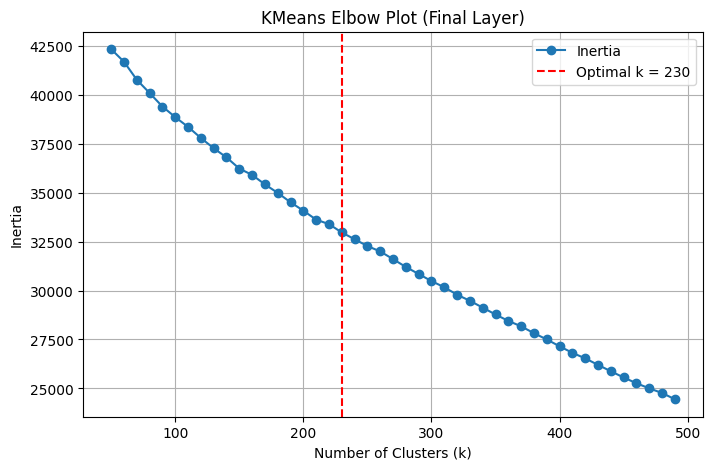

Optimal k for Final Layer: 230


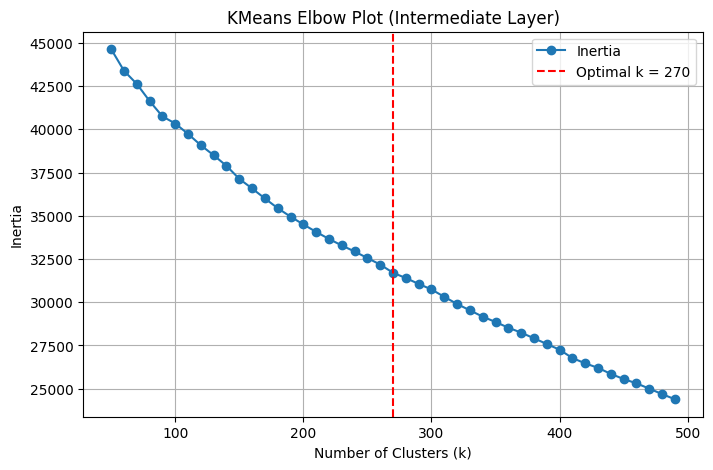

Optimal k for Intermediate Layer: 270


In [19]:
k_range = range(50, 500, 10)

for layer_name, embeddings in zip(["Final", "Intermediate"], [final_embeddings, intermediate_embeddings]):
    inertias = kmeans_elbow(embeddings, k_range)
    optimal_k = plot_elbow_with_knee(k_range, inertias, title=f"KMeans Elbow Plot ({layer_name} Layer)")
    print(f"Optimal k for {layer_name} Layer: {optimal_k}")

In [15]:
print("Cosine Similarity")
print(np.round(final_cos_similar[:5, :5], 2))

Cosine Similarity
[[1.   0.91 0.83 0.78 0.82]
 [0.91 1.   0.85 0.79 0.81]
 [0.83 0.85 1.   0.89 0.87]
 [0.78 0.79 0.89 1.   0.86]
 [0.82 0.81 0.87 0.86 1.  ]]


In [33]:
n = len(sentences)
thres = 0.9

greedy_final = grouping(final_cos_similar, n, thres)
greedy_inter = grouping(intermediate_cos_similar, n, thres)

graph_final = graph_based_grouping(final_cos_similar, n, thres)
graph_inter = graph_based_grouping(intermediate_cos_similar, n, thres)


dbscan_final = clustering_grouping(final_embeddings, thres)
dbscan_inter = clustering_grouping(intermediate_embeddings, thres)

In [34]:
print(f"Greedy Clustering (Final Layer): {len(greedy_final)} clusters")
print(f"Greedy Clustering (Intermediate Layer): {len(greedy_inter)} clusters")

print(f"Graph-based Clustering (Final Layer): {len(graph_final)} clusters")
print(f"Graph-based Clustering (Intermediate Layer): {len(graph_inter)} clusters")

print(f"DBSCAN Clustering (Final Layer): {len(dbscan_final)} clusters")
print(f"DBSCAN Clustering (Intermediate Layer): {len(dbscan_inter)} clusters")

Greedy Clustering (Final Layer): 484 clusters
Greedy Clustering (Intermediate Layer): 283 clusters
Graph-based Clustering (Final Layer): 147 clusters
Graph-based Clustering (Intermediate Layer): 50 clusters
DBSCAN Clustering (Final Layer): 12 clusters
DBSCAN Clustering (Intermediate Layer): 10 clusters


- Count

In [35]:
def get_count(groups):
  group_counts = []
  word_counts = []

  for group in groups:
    group_counts.append(len(group))

    unique_words = set() # prevent duplicates
    for idx in group:
      unique_words.update(sentences[idx].split())
    word_counts.append(len(unique_words))
  return group_counts, word_counts # num of sentence per group, num of word per group

In [36]:
print("--Greedy Grouping--")
greedy_group_counts_final, greedy_word_counts_final = get_count(greedy_final)
greedy_group_counts_inter, greedy_word_counts_inter = get_count(greedy_inter)
print("Final layers' Group Counts of first 5th group:", greedy_group_counts_final[:5])
print("Intermediate layers' Group Counts of first 5th group:", greedy_group_counts_inter[:5])


print("--Graph Grouping--")
graph_group_counts_final, graph_word_counts_final = get_count(graph_final)
graph_group_counts_inter, graph_word_counts_inter = get_count(graph_inter)

print("Final layers' Group Counts of first 5th group:", graph_group_counts_final[:5])
print("Intermediate layers' Group Counts of first 5th group:", graph_group_counts_inter[:5])


print("--dbscan Grouping--")
dbscan_group_counts_final, dbscan_word_counts_final = get_count(dbscan_final)
dbscan_group_counts_inter, dbscan_word_counts_inter = get_count(dbscan_inter)

print("Final layers' Group Counts of first 5th group:", dbscan_group_counts_final[:5])
print("Intermediate layers' Group Counts of first 5th group:", dbscan_group_counts_inter[:5])

--Greedy Grouping--
Final layers' Group Counts of first 5th group: [11, 3, 3, 14, 78]
Intermediate layers' Group Counts of first 5th group: [228, 12, 7, 27, 2]
--Graph Grouping--
Final layers' Group Counts of first 5th group: [1641, 1, 1, 1, 1]
Intermediate layers' Group Counts of first 5th group: [1734, 2, 1, 1, 6]
--dbscan Grouping--
Final layers' Group Counts of first 5th group: [1641, 136, 2, 2, 3]
Intermediate layers' Group Counts of first 5th group: [1734, 2, 41, 6, 3]


In [37]:
print("sanity check using the number of sentences in each group")
print("The total number of sentences in the Final layers:", sum(greedy_group_counts_final))
print("The total number of sentences in the Intermediate layers:", sum(greedy_group_counts_inter))

print("Sanity check result:", n == sum(greedy_group_counts_final) == sum(greedy_group_counts_inter))

sanity check using the number of sentences in each group
The total number of sentences in the Final layers: 1800
The total number of sentences in the Intermediate layers: 1800
Sanity check result: True


In [20]:
from collections import Counter

def count_sentences_per_cluster(embeddings, optimal_k):
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(embeddings)

    cluster_counts = Counter(labels)

    sorted_counts = sorted(cluster_counts.values(), reverse=True)
    return sorted_counts

In [21]:
optimal_k_final, optimal_k_inter = 230, 270

kmeans_group_counts_final = count_sentences_per_cluster(final_embeddings, optimal_k_final)
kmeans_group_counts_inter = count_sentences_per_cluster(intermediate_embeddings, optimal_k_inter)

print("--K-means Grouping--")
print("Final layers' Group Counts of first 5th group:", kmeans_group_counts_final[:5])
print("Intermediate layers' Group Counts of first 5th group:", kmeans_group_counts_inter[:5])

--K-means Grouping--
Final layers' Group Counts of first 5th group: [32, 30, 29, 27, 26]
Intermediate layers' Group Counts of first 5th group: [38, 32, 27, 27, 27]


In [23]:
n = len(sentences)

print("sanity check using the number of sentences in each group")
print("The total number of sentences in the Final layers:", sum(kmeans_group_counts_final))
print("The total number of sentences in the Intermediate layers:", sum(kmeans_group_counts_inter))

print("Sanity check result:", n == sum(kmeans_group_counts_final) == sum(kmeans_group_counts_inter))

sanity check using the number of sentences in each group
The total number of sentences in the Final layers: 1800
The total number of sentences in the Intermediate layers: 1800
Sanity check result: True


### Plotting
1. Plot
2. Loglog Plot
3. Linear Regression

In [38]:
def rearrange_decreasing_order(counts_vector):
  counts_vector = np.array(counts_vector)
  sorted_indices = np.argsort(-counts_vector)
  sorted_sent_counts = counts_vector[sorted_indices]
  return sorted_sent_counts

1. Count-based Plot

In [44]:
def plotting(flag, sorted_sent_counts, model):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"
  # x-axis
  plt.figure(figsize=(16,8))
  plt.plot(range(len(sorted_sent_counts)), sorted_sent_counts, marker='o', linestyle="-")


  plt.xlabel("Groupd Index (Sorted)")
  plt.ylabel("The Number of Sentences per group")
  plt.title(detail + " The Number of Sentences per Group - " + model)
  plt.grid(True)

  plt.show()

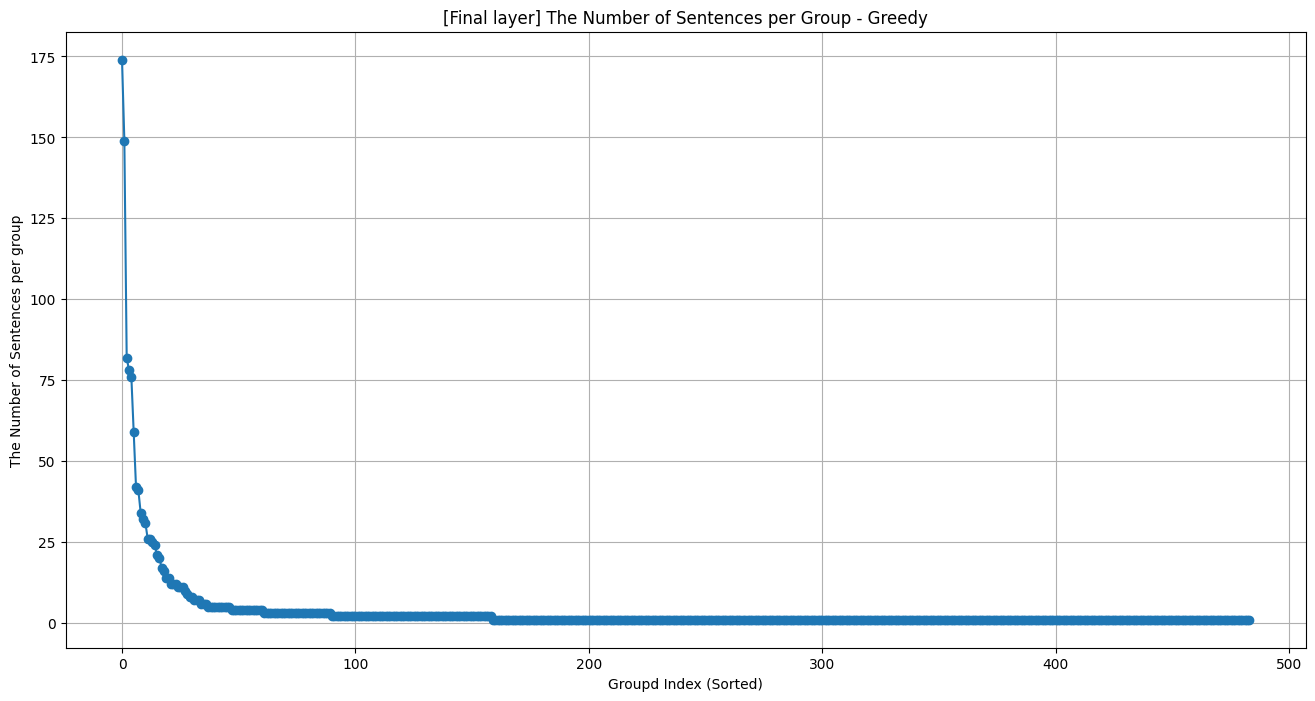

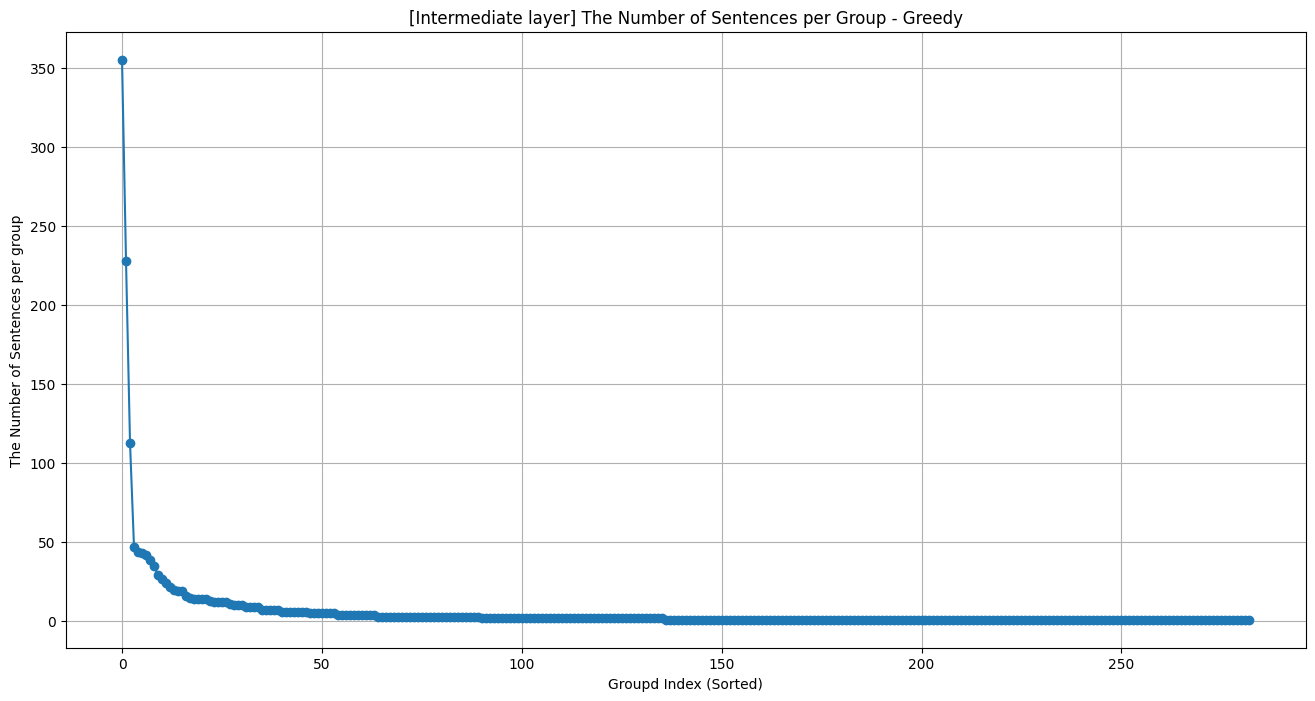

In [45]:
# rearrange in decreaing order (ranking)
sorted_sent_counts_final = rearrange_decreasing_order(greedy_group_counts_final)
sorted_sent_counts_inter = rearrange_decreasing_order(greedy_group_counts_inter)

plotting(True, sorted_sent_counts_final, "Greedy")
plotting(False, sorted_sent_counts_inter, "Greedy")

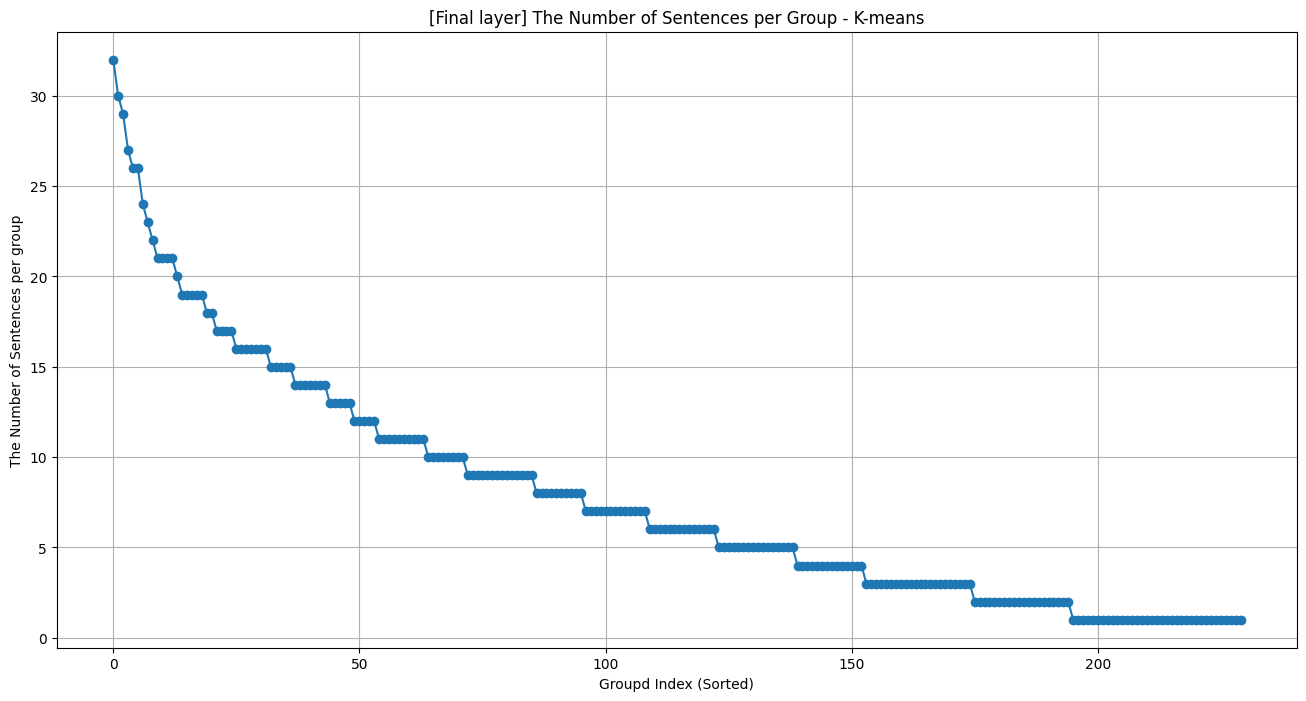

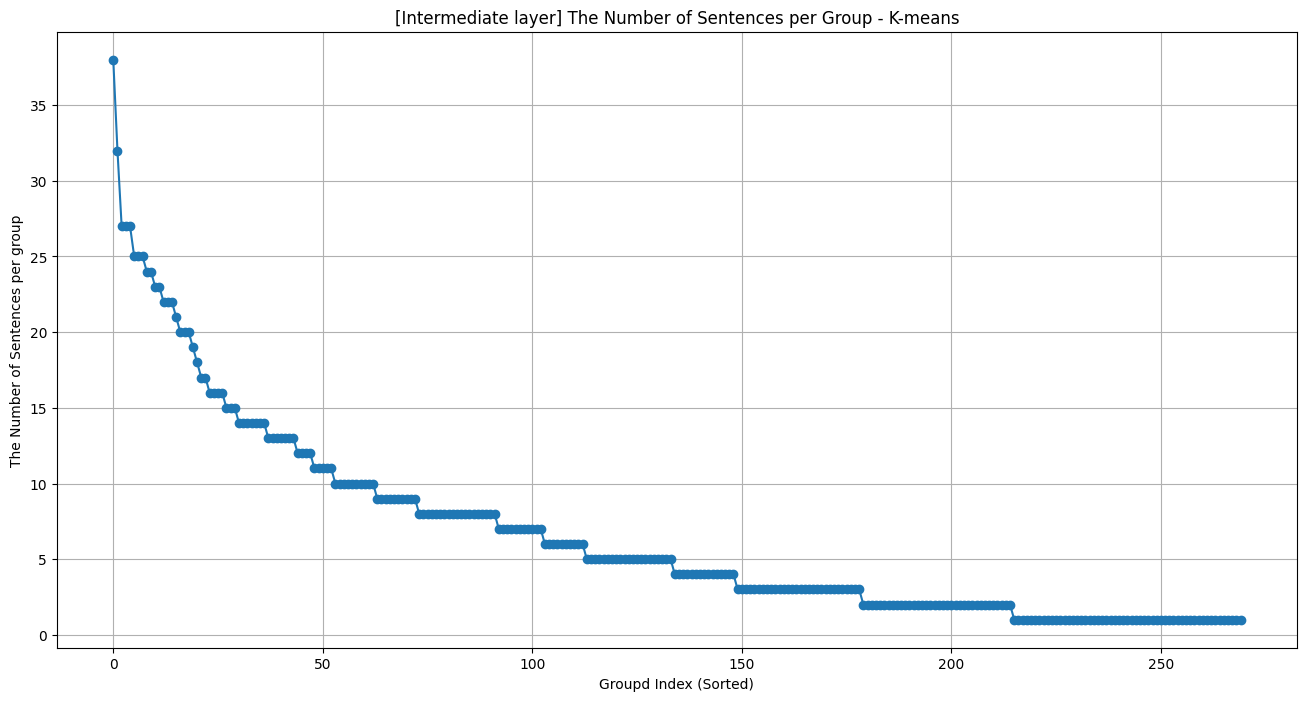

In [46]:
# k-means plotting
plotting(True, kmeans_group_counts_final, "K-means")
plotting(False, kmeans_group_counts_inter, "K-means")

2. Loglog Plot

In [49]:
# Also plot the log log plot using the count matrix.
def loglog_plotting(flag, sorted_sent_counts, model):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"
  plt.figure(figsize=(16,8))
  plt.loglog(range(len(sorted_sent_counts)), sorted_sent_counts, marker="o", linestyle="-")

  plt.xlabel("Groupd Index (Log Scale)")
  plt.ylabel("The Number of Sentences per group (Log Scale)")
  plt.title(detail + "Log-Log Plot of The Number of Sentences per group - " + model)
  plt.grid(True, which="both", linestyle="--")

  plt.show()

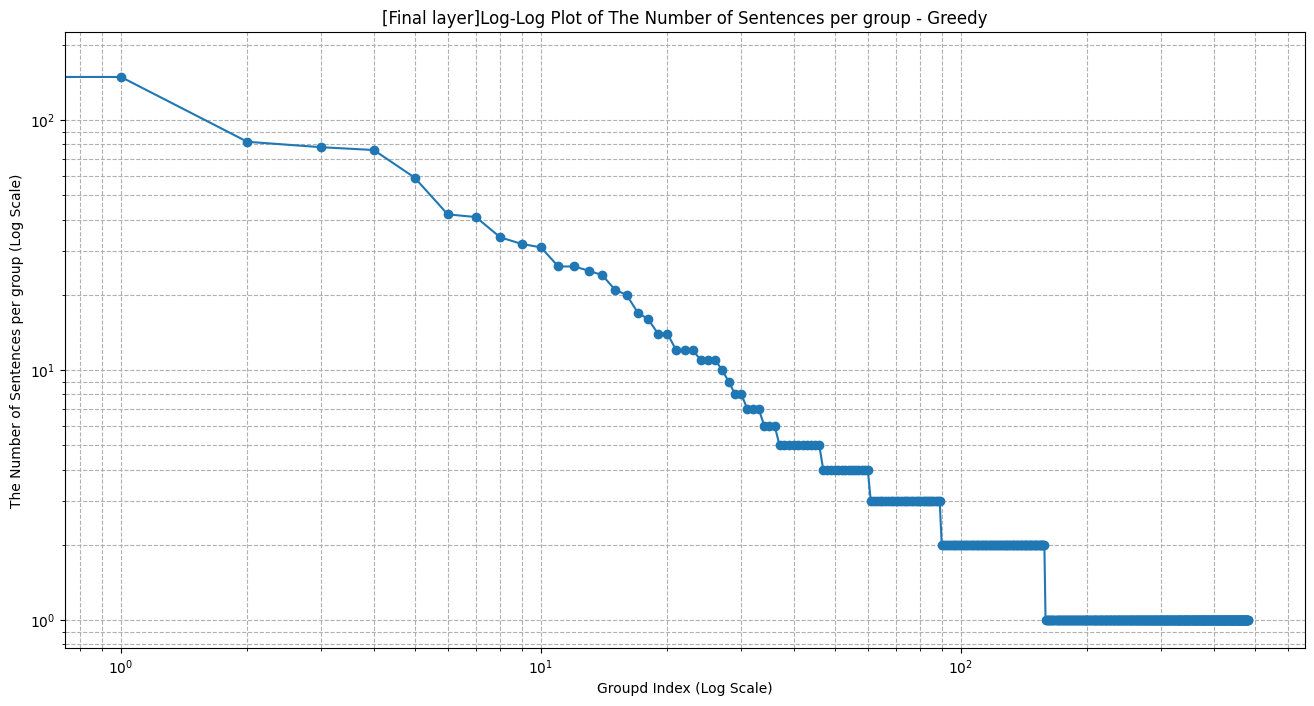

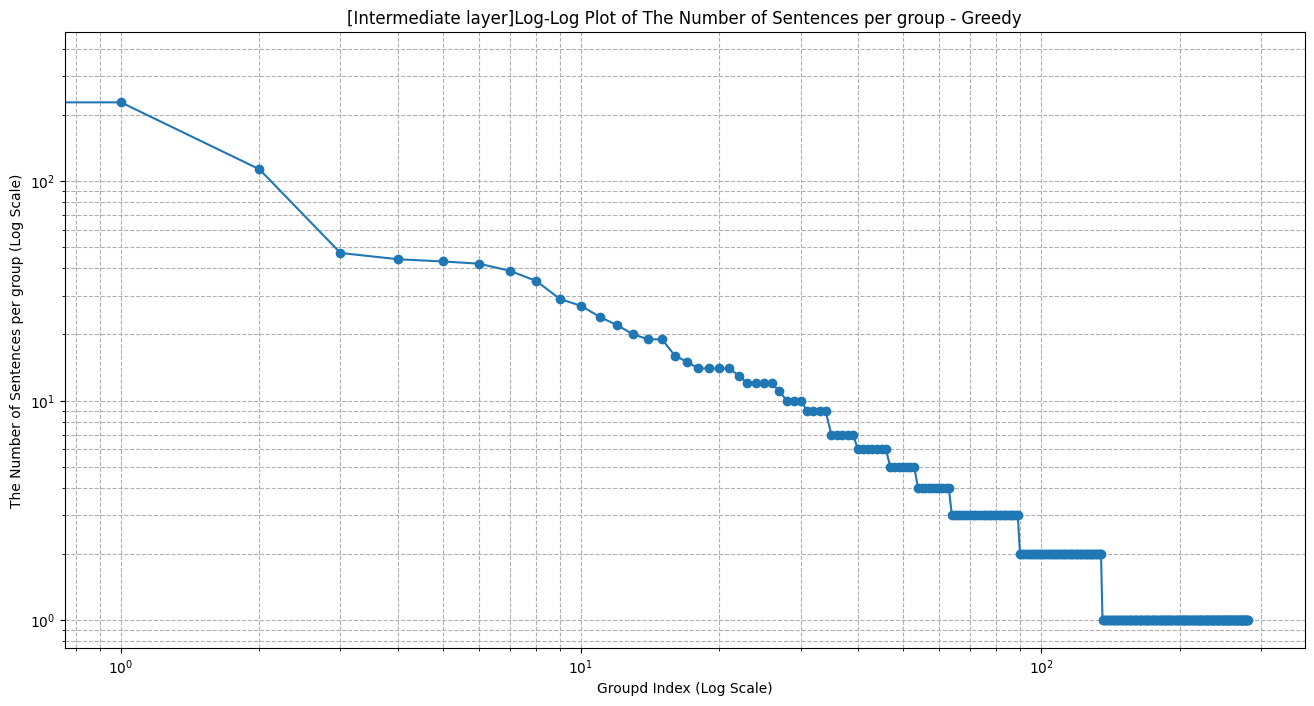

In [50]:
loglog_plotting(True, sorted_sent_counts_final, "Greedy")
loglog_plotting(False, sorted_sent_counts_inter, "Greedy")

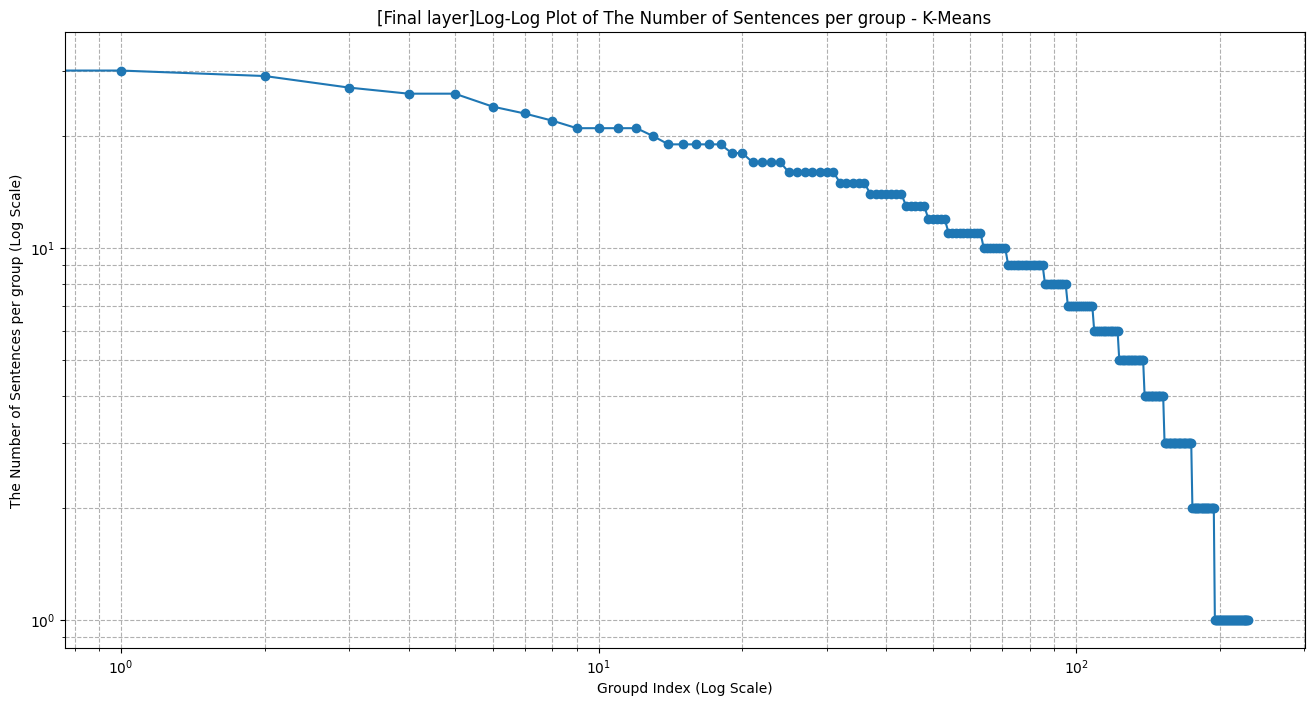

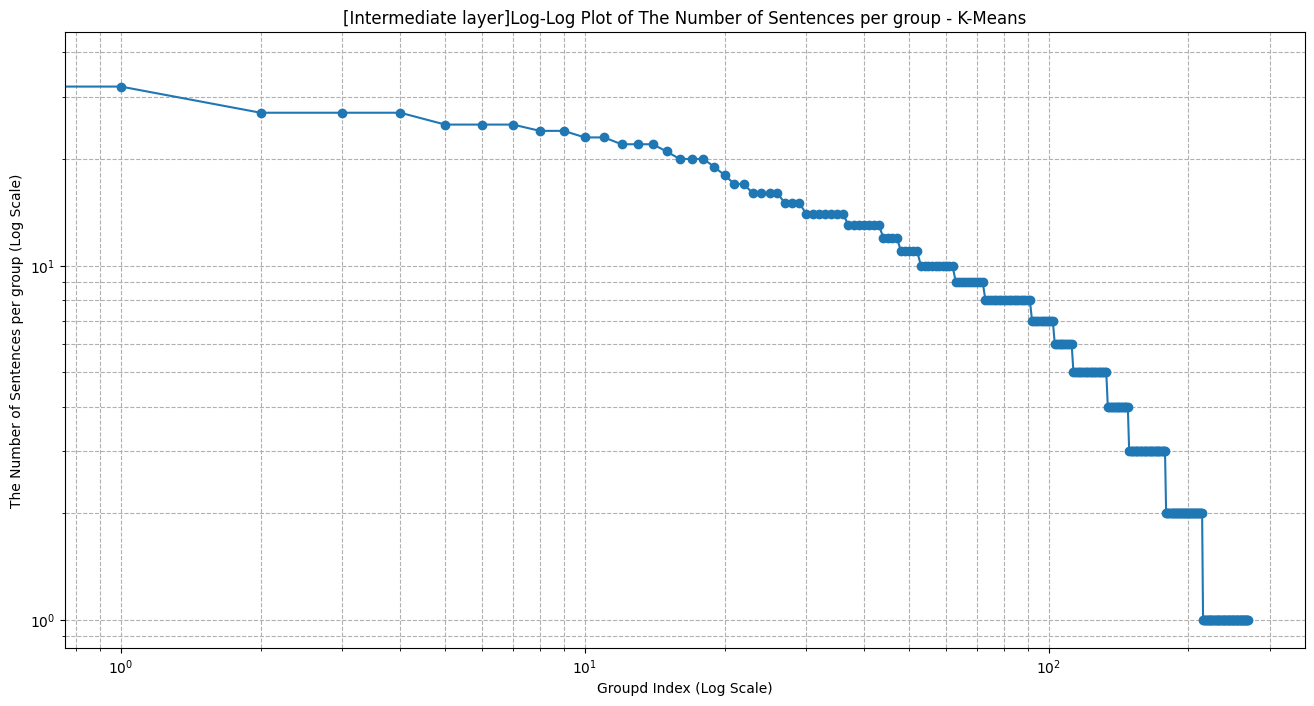

In [51]:
# k-means loglog plotting
loglog_plotting(True, kmeans_group_counts_final, "K-Means")
loglog_plotting(False, kmeans_group_counts_inter, "K-Means")

3. Linear Regression

In [29]:
from scipy.stats import linregress

def linear_regression(sorted_sent_counts):
  x = np.log10(np.arange(1, len(sorted_sent_counts)+1))
  y = np.log10(sorted_sent_counts)

  # linear regression
  slope, intercept, r_val, p_val, std_err = linregress(x, y)

  # regression prediction
  y_pred = slope * x + intercept

  return x, y, slope, intercept, r_val, p_val, y_pred

In [30]:
def return_linear_regression_result(flag, sorted_sent_counts):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"

  x, y, slope, intercept, r_val, p_val, y_pred = linear_regression(sorted_sent_counts)

  print(detail + "Linear Regression Prediction: y = slope * x + intercept")
  print(f"y ={slope:.2f}x + {intercept:.2f}")

  print(f"Linear Regression Results:")
  print(f"   - Slope: {slope:.4f}")
  print(f"   - Intercept: {intercept:.4f}")
  print(f"   - R-squared: {r_val**2:.4f}")
  print(f"   - P-value: {p_val:.4e}")

In [52]:
# k-means
print("--- K-means ---")
return_linear_regression_result(True, kmeans_group_counts_final)
print()
return_linear_regression_result(False, kmeans_group_counts_inter)

--- K-means ---
[Final layer]Linear Regression Prediction: y = slope * x + intercept
y =-0.87x + 2.39
Linear Regression Results:
   - Slope: -0.8664
   - Intercept: 2.3946
   - R-squared: 0.7275
   - P-value: 2.6956e-66

[Intermediate layer]Linear Regression Prediction: y = slope * x + intercept
y =-0.93x + 2.49
Linear Regression Results:
   - Slope: -0.9323
   - Intercept: 2.4883
   - R-squared: 0.8033
   - P-value: 1.2547e-96


In [53]:
## Greedy
print("-- Greedy --")
return_linear_regression_result(True, sorted_sent_counts_final)
print()
return_linear_regression_result(False, sorted_sent_counts_inter)

-- Greedy --
[Final layer]Linear Regression Prediction: y = slope * x + intercept
y =-0.86x + 2.14
Linear Regression Results:
   - Slope: -0.8586
   - Intercept: 2.1370
   - R-squared: 0.9127
   - P-value: 2.5624e-257

[Intermediate layer]Linear Regression Prediction: y = slope * x + intercept
y =-1.09x + 2.54
Linear Regression Results:
   - Slope: -1.0917
   - Intercept: 2.5381
   - R-squared: 0.9692
   - P-value: 2.2331e-214


In [54]:
def linear_regression_plotting(flag, sorted_sent_counts, model):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"

  x, y, slope, intercept, r_val, p_val, y_pred = linear_regression(sorted_sent_counts)

  plt.figure(figsize=(16,8))
  plt.scatter(x, y, label="Sentences counts (Log-Log)", alpha=0.8, marker="o")
  plt.plot(x, y_pred, color = "red", label=f"Linear Fit: y={slope:.2f}x + {intercept:.2f}")
  plt.text(0.1, 1.2, f"$R^2$ = {r_val**2:.4f}", fontsize=14, color="black")

  plt.xlabel("Group Index (Log scale)")
  plt.ylabel("The Number of Sentences per group (Log scale)")
  plt.title(detail + "Linear Regression on Log-Log Scale - " + model)
  plt.legend()
  plt.grid(True)

  plt.show()

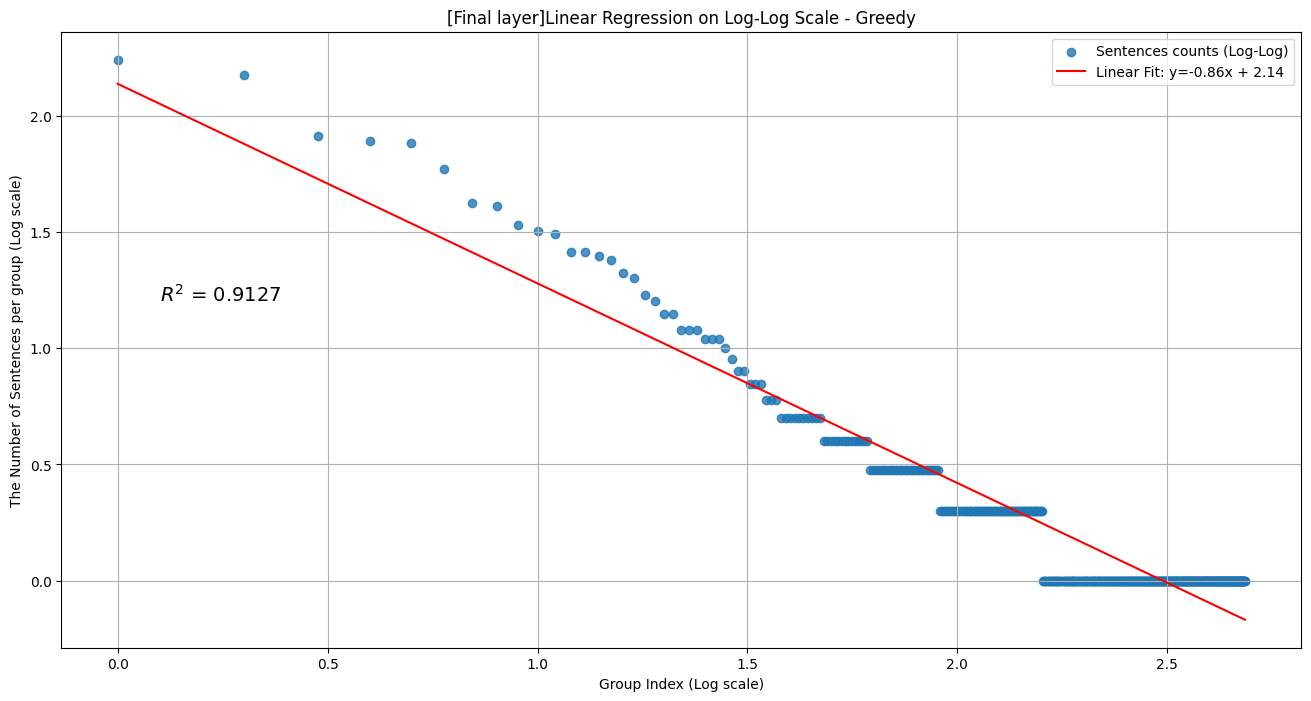

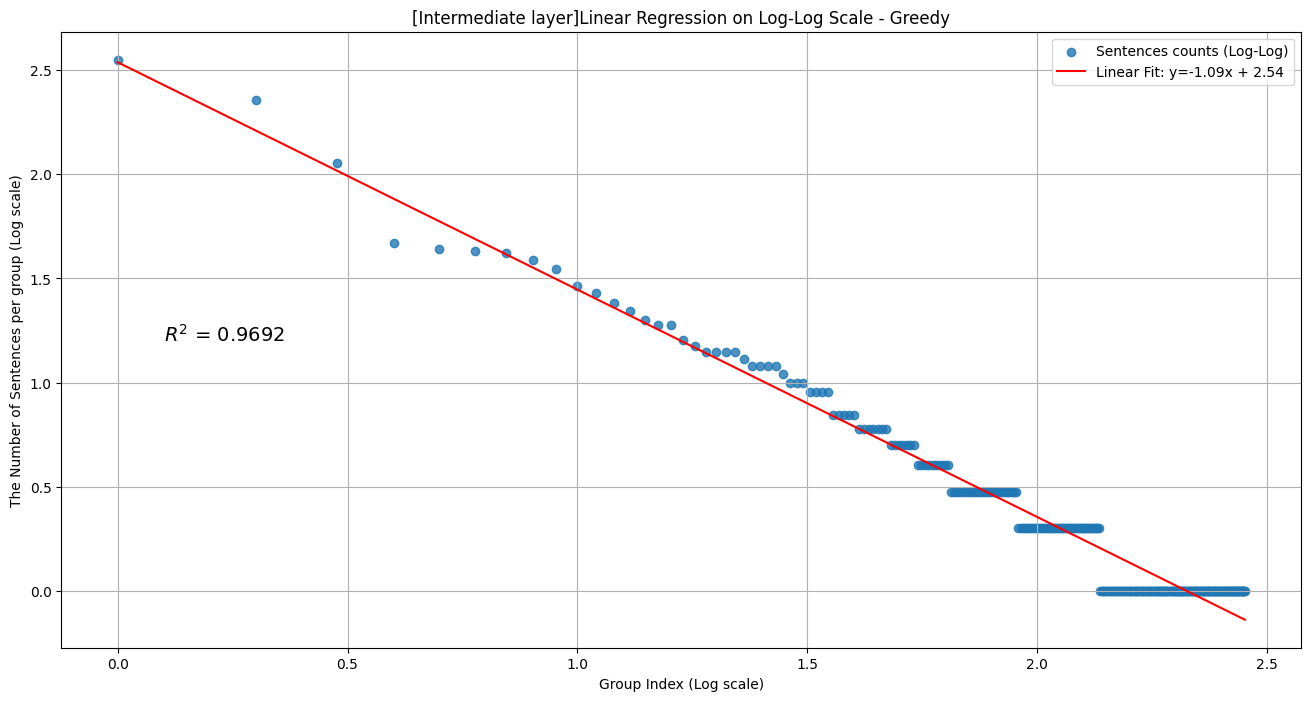

In [55]:
linear_regression_plotting(True, sorted_sent_counts_final, "Greedy")
linear_regression_plotting(False, sorted_sent_counts_inter, "Greedy")

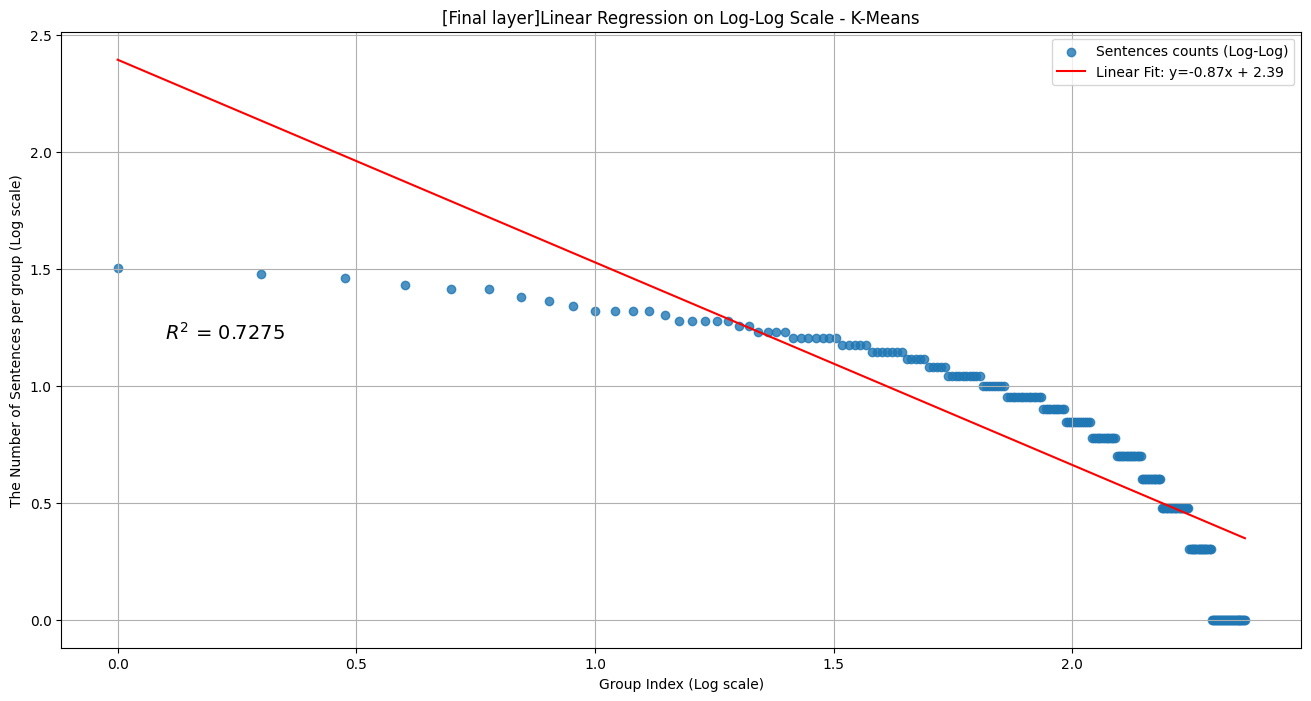

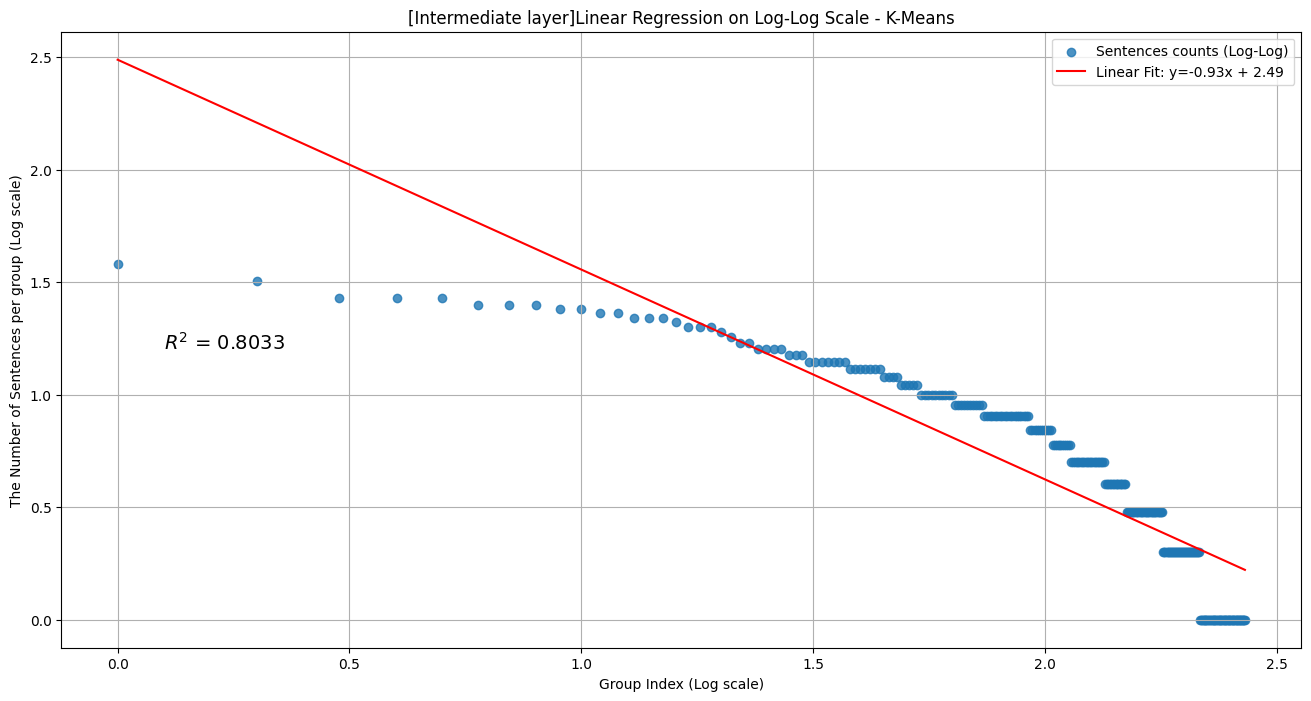

In [56]:
linear_regression_plotting(True, kmeans_group_counts_final, "K-Means")
linear_regression_plotting(False, kmeans_group_counts_inter, "K-Means")